In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, BatchNormalization, Dropout
from keras import layers
from keras.regularizers import l2,l1
from sklearn.model_selection import StratifiedKFold as kfold

In [7]:
# Comment this part out if you want to mount the google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
data=pd.read_csv('csv/garments_worker_productivity.csv')

In [9]:
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [10]:
data=data.drop('date',axis=1)

In [11]:
data.isna().sum()

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [12]:
data.dropna(inplace=True)

In [13]:
data.reset_index(drop=True,inplace=True)

In [14]:
X=data.drop('actual_productivity',axis=1)
y=data['actual_productivity']

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([("t1", OneHotEncoder(), [1]),("t2", OrdinalEncoder(), [0,2])],remainder='passthrough')
X=ct.fit_transform(X)

In [16]:
X

array([[ 1. ,  0. ,  3. , ...,  0. ,  0. , 59. ],
       [ 1. ,  0. ,  3. , ...,  0. ,  0. , 30.5],
       [ 1. ,  0. ,  3. , ...,  0. ,  0. , 30.5],
       ...,
       [ 1. ,  1. ,  5. , ...,  0. ,  1. , 57. ],
       [ 1. ,  1. ,  5. , ...,  0. ,  1. , 38. ],
       [ 1. ,  1. ,  5. , ...,  0. ,  1. , 57. ]], shape=(691, 13))

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X=scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
X.shape

(691, 13)

In [20]:
# Wihout regularisation or dropout
model=Sequential()
model.add(Dense(13, input_shape=(13,), activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(1, activation='relu'))

c:\Users\piumi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# with dropout
DROP=0.05
model=Sequential()
model.add(Dense(13, input_shape=(13,), activation='swish'))
model.add(Dropout(DROP))
model.add(Dense(9,activation='swish'))
model.add(Dropout(DROP))
model.add(Dense(9,activation='swish'))
model.add(Dropout(DROP))
model.add(Dense(1, activation='swish'))

In [22]:
# with regularisation
model=Sequential()
model.add(Dense(13, input_shape=(13,), activation='relu',kernel_regularizer=l1(0.01), bias_regularizer=l2(0.01)))
model.add(Dense(9,activation='relu',kernel_regularizer=l2(0.01)))
model.add(Dense(9,activation='relu',kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation='relu',activity_regularizer=l2(0.01)))

In [23]:
# with regularisation, another setup
model=Sequential()
model.add(Dense(13, input_shape=(13,), activation='swish',kernel_regularizer=l1(0.001)))
model.add(Dense(9,activation='swish',kernel_regularizer=l2(0.001)))
model.add(Dense(9,activation='swish',kernel_regularizer=l2(0.001)))
model.add(Dense(1, activation='swish'))

In [24]:
# Compiling without callback
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse'])

In [25]:
# Training without callback
history = model.fit(X_train, y_train, epochs=200, batch_size=50, validation_split=0.3)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.6302 - mse: 0.5742 - val_loss: 0.6248 - val_mse: 0.5693
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5929 - mse: 0.5376 - val_loss: 0.5870 - val_mse: 0.5321
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5550 - mse: 0.5003 - val_loss: 0.5473 - val_mse: 0.4930
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5139 - mse: 0.4598 - val_loss: 0.5035 - val_mse: 0.4496
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4687 - mse: 0.4149 - val_loss: 0.4530 - val_mse: 0.3994
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4156 - mse: 0.3621 - val_loss: 0.3942 - val_mse: 0.3407
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3538 - mse: 0.3003 - val_loss: 0.3264 - val_mse: 0.2729
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2834 - mse: 0.2299 - val_loss: 0.2509 - val_mse: 0.1973
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2078 - mse: 

In [26]:
# Defining callback
callback1 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=60,min_delta=0.00001, restore_best_weights=True)

In [27]:
# Training with callback
history = model.fit(X_train, y_train, epochs=1000, batch_size=50, validation_split=0.3, callbacks=[callback1])

Epoch 1/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0153 - mse: 0.0054 - val_loss: 0.0168 - val_mse: 0.0069
Epoch 2/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0153 - mse: 0.0054 - val_loss: 0.0167 - val_mse: 0.0069
Epoch 3/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0152 - mse: 0.0054 - val_loss: 0.0166 - val_mse: 0.0069
Epoch 4/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0152 - mse: 0.0054 - val_loss: 0.0166 - val_mse: 0.0069
Epoch 5/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - mse: 0.0054 - val_loss: 0.0165 - val_mse: 0.0068
Epoch 6/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0150 - mse: 0.0054 - val_loss: 0.0164 - val_mse: 0.0068
Epoch 7/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0150 - mse: 0.0054 - val_loss: 0.0164 - val_mse: 0.0068
Epoch 8/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0149 - mse: 0.0054 - val_loss: 0.0163 - val_mse: 0.0068
Epoch 9/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.014

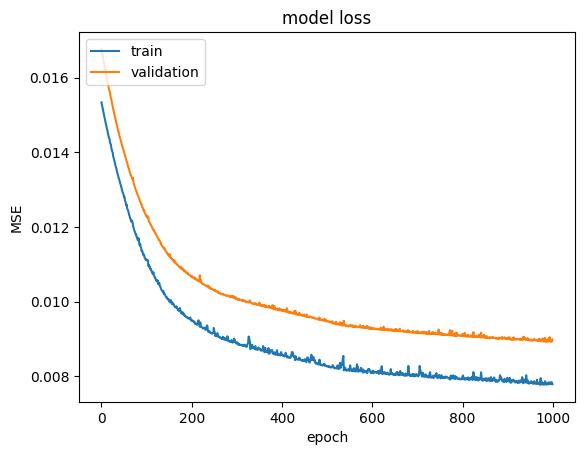

In [28]:
# Plotting the error
from matplotlib import pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [29]:
# Predicting
pred=model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [30]:
from sklearn.metrics import r2_score
# real value
print('\nThe R^2 score is {}'.format(r2_score(y_test,pred)))

# 1%


The R^2 score is 0.8020529166141833
